Train Shape: (207146, 84)
Test Shape: (136743, 84)
After removing tiny classes:
Label
Normal        68423
DoS           52471
DDoS          48413
Probe         36372
BFA            1110
Web-Attack      192
BOTNET          164
Name: count, dtype: int64
After PCA Train: (207145, 15)
Epoch 1/30
729/729 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.1633 - val_loss: 0.0791
Epoch 2/30
729/729 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0746 - val_loss: 0.0739
Epoch 3/30
729/729 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0654 - val_loss: 0.0730
Epoch 4/30
729/729 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0645 - val_loss: 0.0727
Epoch 5/30
729/729 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0634 - val_loss: 0.0725
Epoch 6/30
729/729 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0629 - val_loss: 0.0723
Epoch 7/30
729/729 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0628 - val_loss: 0.0722
Epoch 8/30
729/729 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0628 - val_loss: 0.0722
Epoch 9/30
729/729 ━━━━━━━━━━━

C:\Users\lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\lenovo\anaconda3\Lib\site-packages\s

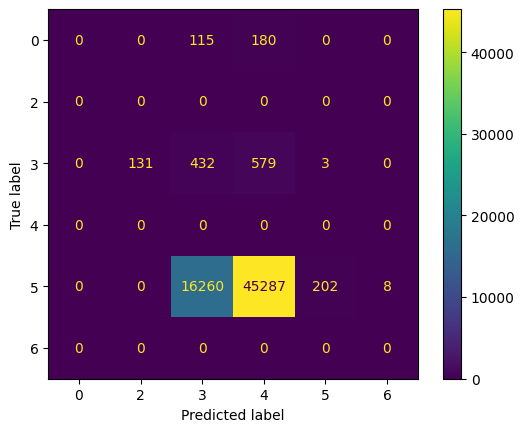

Cross-validation Accuracy: 0.9676941273021313


In [2]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score

from sklearn.ensemble import HistGradientBoostingClassifier

import matplotlib.pyplot as plt

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping


# ==============================
# 1. LOAD DATASETS
# ==============================

normal = pd.read_csv("Normal_data.csv")
meta = pd.read_csv("metasploitable-2.csv")
ovs = pd.read_csv("OVS.csv")

train_df = pd.concat([normal, ovs], axis=0)
test_df = meta.copy()

print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)


# ==============================
# 2. CLEANING
# ==============================

train_df.drop_duplicates(inplace=True)
train_df.dropna(inplace=True)

test_df.drop_duplicates(inplace=True)
test_df.dropna(inplace=True)


# ==============================
# 3. REMOVE TINY CLASSES
# ==============================

counts = train_df["Label"].value_counts()
valid_classes = counts[counts > 50].index

train_df = train_df[train_df["Label"].isin(valid_classes)]
test_df = test_df[test_df["Label"].isin(valid_classes)]

print("After removing tiny classes:")
print(train_df["Label"].value_counts())


# ==============================
# 4. ENCODE CATEGORICAL
# ==============================

le = LabelEncoder()

for col in train_df.columns:
    if train_df[col].dtype == 'object':
        le.fit(pd.concat([train_df[col], test_df[col]]))
        train_df[col] = le.transform(train_df[col])
        test_df[col] = le.transform(test_df[col])


# ==============================
# 5. FEATURES / LABEL
# ==============================

X_train = train_df.drop("Label", axis=1)
y_train = train_df["Label"]

X_test = test_df.drop("Label", axis=1)
y_test = test_df["Label"]


# ==============================
# 6. SCALING
# ==============================

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# ==============================
# 7. PCA
# ==============================

pca = PCA(n_components=15)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("After PCA Train:", X_train_pca.shape)


# ==============================
# ⭐ 8. DEEP AUTOENCODER
# ==============================

input_dim = X_train_pca.shape[1]

input_layer = Input(shape=(input_dim,))

# -------- Encoder (DEEP) ----------
x = Dense(12, activation='relu')(input_layer)
x = Dense(8, activation='relu')(x)
encoded = Dense(6, activation='relu')(x)   # bottleneck

# -------- Decoder ----------
x = Dense(8, activation='relu')(encoded)
x = Dense(12, activation='relu')(x)
decoded = Dense(input_dim, activation='sigmoid')(x)

autoencoder = Model(input_layer, decoded)
encoder = Model(input_layer, encoded)

autoencoder.compile(optimizer='adam', loss='mse')


# Early stopping prevents overfitting
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

autoencoder.fit(
    X_train_pca, X_train_pca,
    epochs=30,
    batch_size=256,   # larger batch = faster training
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)


# ==============================
# 9. EXTRACT DEEP FEATURES
# ==============================

X_train_enc = encoder.predict(X_train_pca)
X_test_enc = encoder.predict(X_test_pca)

print("Encoded Shape:", X_train_enc.shape)


# ==============================
# ⭐ 10. HISTGRADIENTBOOSTING
# (LightGBM-like)
# ==============================

hgb = HistGradientBoostingClassifier(
    max_iter=150,
    max_depth=10,
    learning_rate=0.05,
    random_state=42
)

hgb.fit(X_train_enc, y_train)

y_pred = hgb.predict(X_test_enc)


# ==============================
# 11. RESULTS
# ==============================

print("\nFINAL RESULTS\n")

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


# ==============================
# 12. CONFUSION MATRIX
# ==============================

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()


# ==============================
# 13. CROSS VALIDATION
# ==============================

scores = cross_val_score(hgb, X_train_enc, y_train, cv=5)

print("Cross-validation Accuracy:", scores.mean())


Cross-validation Accuracy: 0.9771126505587875

CROSS-VALIDATION METRICS

Precision: 0.9786704973958645
Recall: 0.9750174998189673
F1 Score: 0.9758581648543645


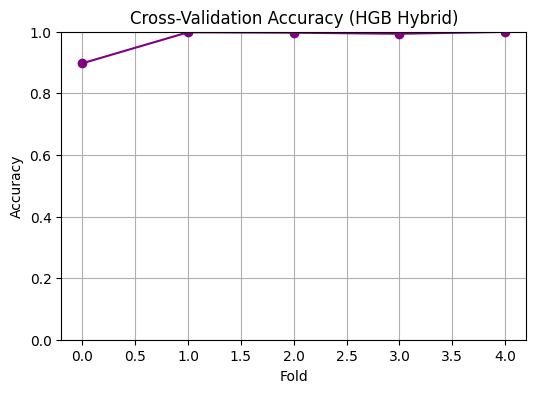

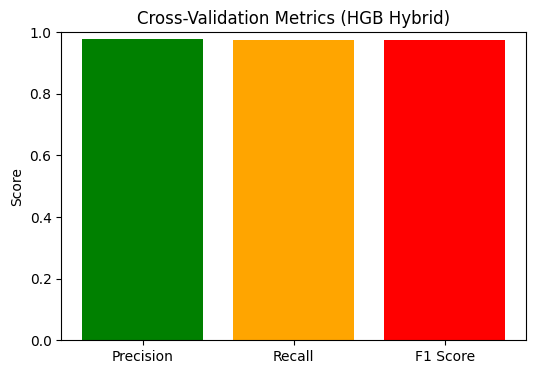

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import HistGradientBoostingClassifier

# ==============================
# PIPELINE (CORRECT CV METHOD)
# ==============================
pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('pca', PCA(n_components=15)),
    ('hgb', HistGradientBoostingClassifier(
        max_iter=150,
        max_depth=10,
        learning_rate=0.05,
        random_state=42
    ))
])

# ==============================
# CROSS VALIDATION ACCURACY
# ==============================
scores = cross_val_score(pipeline, X_train, y_train, cv=5)

print("Cross-validation Accuracy:", scores.mean())

# ==============================
# CROSS VALIDATION PREDICTIONS
# ==============================
y_cv_pred = cross_val_predict(pipeline, X_train, y_train, cv=5)

# ==============================
# METRICS
# ==============================
precision = precision_score(y_train, y_cv_pred, average='weighted')
recall = recall_score(y_train, y_cv_pred, average='weighted')
f1 = f1_score(y_train, y_cv_pred, average='weighted')

print("\nCROSS-VALIDATION METRICS\n")
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

# ==============================
# GRAPH 1: CV ACCURACY PER FOLD
# ==============================
plt.figure(figsize=(6,4))
plt.plot(scores, marker='o', color='purple')
plt.title("Cross-Validation Accuracy (HGB Hybrid)")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.grid()
plt.show()

# ==============================
# GRAPH 2: METRICS BAR GRAPH
# ==============================
metrics = [precision, recall, f1]
labels = ["Precision", "Recall", "F1 Score"]

plt.figure(figsize=(6,4))
plt.bar(labels, metrics, color=['green','orange','red'])
plt.ylim(0,1)
plt.title("Cross-Validation Metrics (HGB Hybrid)")
plt.ylabel("Score")
plt.show()